# Portafolio Cuantitativo Neutral al Mercado

## Pairs Trading en Forex mediante Cointegración y Filtro de Kalman

**Autor:** Edgar Samuel Oropeza García

**Institución:** Tec de Monterrey

**Área:** Finanzas Cuantitativas, Economía Estadística y Machine Learning

---

Este notebook implementa, paso a paso, un sistema de *Pairs Trading* (arbitraje estadístico) sobre el mercado de divisas (Forex). El objetivo es identificar pares de monedas cointegradas, estimar su relación de cobertura de forma dinámica con un Filtro de Kalman, y generar señales de entrada/salida basadas en la reversión a la media del spread — buscando retornos independientes de la dirección general del mercado (*market-neutral*).

## Instalación de Librerías

Se instalan las librerías necesarias para cada fase del proyecto. Las marcadas como opcionales corresponden a la extensión GNN (alternativa a TDA), que no es parte obligatoria del pipeline base.

In [4]:
# Fase 1
# !pip install yfinance oandapyV20 pandas numpy

# Fase 2
# !pip install statsmodels scipy scikit-learn gudhi ripser kepler-mapper networkx

# Fase 3
# !pip install pykalman filterpy

# Fase 4
#!pip install hmmlearn

# Fase 5
# !pip install vectorbt quantstats empyrical

# Opcional — GNN (alternativa a TDA en Fase 2)
# !pip install torch torch-geometric

## Fase 1: DAtos y EDA

Descargamos los precios históricos de las divisas del universo (12 monedas frente al USD), los alineamos en el tiempo y separamos cronológicamente en entrenamiento (in-sample) y validación (out-of-sample). Esta separación es clave: todo lo que se calibre en las fases siguientes (cointegración, umbrales, Kalman) se hace con el tramo de entrenamiento, para que el tramo de validación sirva como una prueba honesta.

In [11]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

pd.set_option('display.max_columns', None)

# Universo de 12 divisas de alta liquidez, expresadas como pares contra USD (formato yfinance)
tickers = {
    'EURUSD': 'EURUSD=X',
    'GBPUSD': 'GBPUSD=X',
    'AUDUSD': 'AUDUSD=X',
    'NZDUSD': 'NZDUSD=X',
    'USDJPY': 'USDJPY=X',
    'USDCAD': 'USDCAD=X',
    'USDCHF': 'USDCHF=X',
    'USDMXN': 'USDMXN=X',
    'USDCNY': 'USDCNY=X',
    'USDSEK': 'USDSEK=X',
    'USDNOK': 'USDNOK=X',
    'USDSGD': 'USDSGD=X',
}

In [13]:
# yfinance limita los intervalos de 60m a los últimos ~730 días
end_date = datetime.today()
start_date = end_date - timedelta(days=729)

raw_data = yf.download(
    list(tickers.values()),
    start=start_date.strftime('%Y-%m-%d'),
    end=end_date.strftime('%Y-%m-%d'),
    interval='60m'
)['Close']

raw_data.columns = tickers.keys()
raw_data.head()

[*********************100%***********************]  12 of 12 completed


,EURUSD,GBPUSD,AUDUSD,NZDUSD,USDJPY,USDCAD,USDCHF,USDMXN,USDCNY,USDSEK,USDNOK,USDSGD
Datetime,,,,,,,,,,,,
2024-09-02 00:00:00+01:00,0.677048,1.104728,1.313042,0.624844,1.34906,0.85070,NaN,146.399002,19.700001,10.60539,10.27027,1.30603
2024-09-02 01:00:00+01:00,0.677690,1.105705,1.313405,0.625078,1.34886,0.85002,NaN,146.188004,19.725220,10.60270,10.26041,1.30562
2024-09-02 02:00:00+01:00,0.677007,1.105461,1.312646,0.624298,1.34936,0.85002,7.1042,146.212997,19.711960,10.61036,10.26036,1.30611
2024-09-02 03:00:00+01:00,0.676682,1.105461,1.312663,0.623753,1.34972,0.84973,7.1059,145.966003,19.742001,10.61348,10.26684,1.30624
2024-09-02 04:00:00+01:00,0.676636,1.105217,1.312836,0.623986,1.34963,0.84975,7.1033,145.945999,19.735001,10.61060,10.27119,1.30613


In [14]:
# Forex opera 24/5; puede haber pequeños huecos entre calendarios de distintos pares.
data = raw_data.copy()
data = data.ffill().dropna()

print(f"Rango de fechas: {data.index.min()} a {data.index.max()}")
print(f"Número de observaciones: {len(data)}")
data.head()

Rango de fechas: 2024-09-02 02:00:00+01:00 a 2026-08-31 23:00:00+01:00
Número de observaciones: 12411


,EURUSD,GBPUSD,AUDUSD,NZDUSD,USDJPY,USDCAD,USDCHF,USDMXN,USDCNY,USDSEK,USDNOK,USDSGD
Datetime,,,,,,,,,,,,
2024-09-02 02:00:00+01:00,0.677007,1.105461,1.312646,0.624298,1.34936,0.85002,7.1042,146.212997,19.711960,10.61036,10.26036,1.30611
2024-09-02 03:00:00+01:00,0.676682,1.105461,1.312663,0.623753,1.34972,0.84973,7.1059,145.966003,19.742001,10.61348,10.26684,1.30624
2024-09-02 04:00:00+01:00,0.676636,1.105217,1.312836,0.623986,1.34963,0.84975,7.1033,145.945999,19.735001,10.61060,10.27119,1.30613
2024-09-02 05:00:00+01:00,0.676315,1.105094,1.312629,0.623480,1.34985,0.84983,7.1035,145.929001,19.729000,10.61322,10.27263,1.30642
2024-09-02 06:00:00+01:00,0.676650,1.105828,1.313215,0.623597,1.34955,0.84935,7.1019,146.108002,19.709101,10.60465,10.26861,1.30613


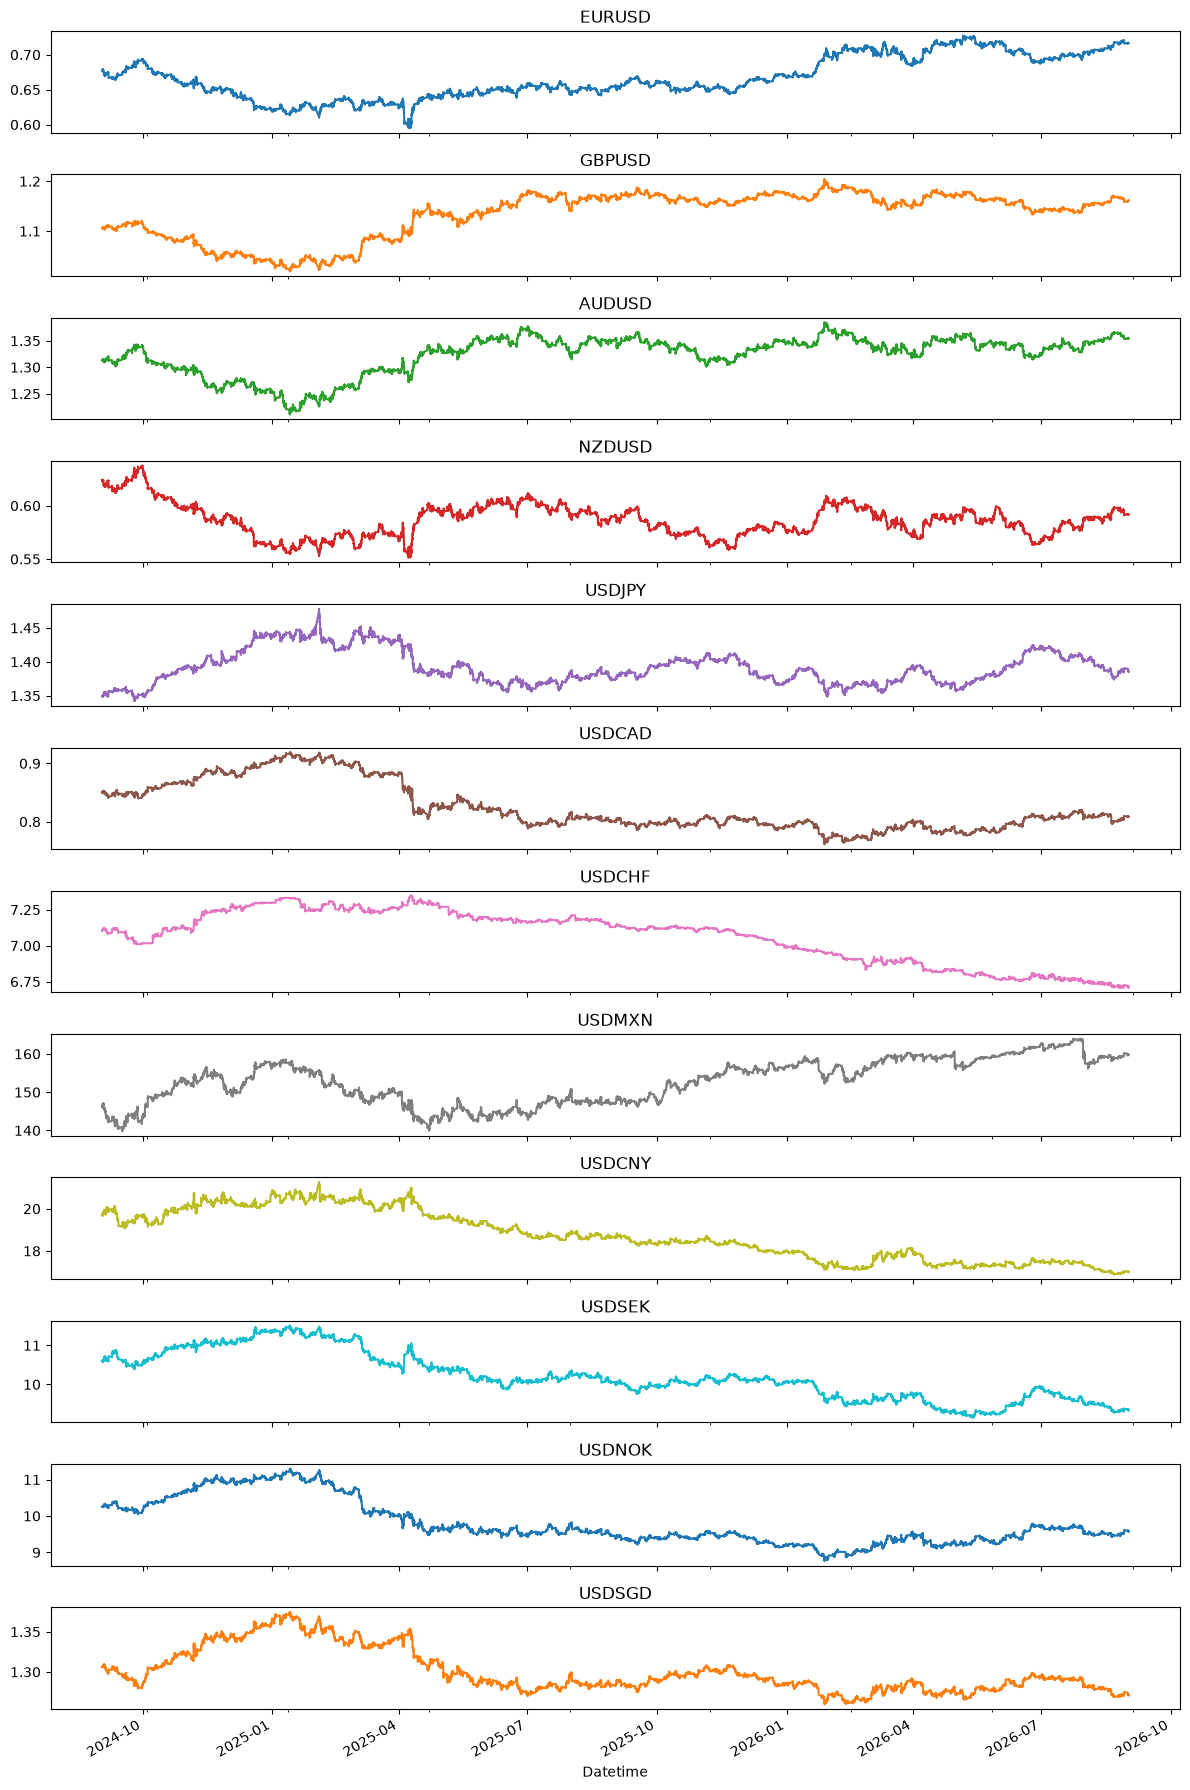

In [15]:
data.plot(subplots=True, figsize=(12, 18), title=list(data.columns), legend=False)
plt.tight_layout()
plt.show()

In [16]:
# División cronológica, NO aleatoria: mezclar fechas al azar filtraría información
# del futuro hacia el pasado (data leakage).
split_idx = int(len(data) * 0.70)

train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

print(f"Entrenamiento (In-Sample):     {train.index.min()} a {train.index.max()}  ({len(train)} obs)")
print(f"Validación (Out-of-Sample):    {test.index.min()} a {test.index.max()}  ({len(test)} obs)")

Entrenamiento (In-Sample):     2024-09-02 02:00:00+01:00 a 2026-01-23 09:00:00+00:00  (8687 obs)
Validación (Out-of-Sample):    2026-01-23 10:00:00+00:00 a 2026-08-31 23:00:00+01:00  (3724 obs)


## Fase 2: Identificación Econométrica de Cointegración

Antes de armar cualquier señal de trading, hay que confirmar qué pares de divisas están relacionadas en el largo plazo (cointegrados), y no solo correlacionados por casualidad. Todo esto se calibra **únicamente con `train`** — el tramo de validación (`test`) no se toca hasta el backtest final.

1. **ADF** sobre cada serie individual, para confirmar que son I(1) (no estacionarias por sí solas).
2. **Engle-Granger** par a par, para encontrar combinaciones de 2 divisas cuyo residuo sí sea estacionario.
3. **Johansen** sobre el universo completo, para detectar relaciones de equilibrio en canastas de 3+ divisas.